In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler,robust_scale
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Activation,BatchNormalization
from tensorflow.keras.regularizers import L1, L2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, Adam

from kerastuner.tuners import RandomSearch,GridSearch
from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.over_sampling import SMOTE


In [218]:
df  = pd.read_csv(r"C:\Users\Admin\Downloads\Predicting Irrigation Need.csv")
df_test  = pd.read_csv(r"C:\Users\Admin\Downloads\test.csv")

In [219]:
df.drop('id',axis=1,inplace=True)
sub = df_test[['id']]
df_test.drop('id',axis=1,inplace=True)


In [220]:
df

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High
629998,Clay,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,5.00,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,0.79,Yes,90.00,East,Low


In [221]:
df.shape


(630000, 20)

In [222]:
df.duplicated().sum()

np.int64(0)

In [223]:
df.isnull().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [224]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

In [225]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.0,6.48,0.92,4.80,5.69,6.44,7.27,8.20
Soil_Moisture,630000.0,37.30,16.38,8.00,23.34,37.75,51.27,64.99
Organic_Carbon,630000.0,0.92,0.37,0.30,0.61,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.74,0.95,0.10,0.93,1.74,2.58,3.50
Temperature_C,630000.0,27.00,8.62,12.00,19.52,26.96,34.54,42.00
Humidity,630000.0,61.56,19.71,25.00,45.39,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.21,612.99,0.38,954.57,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.51,2.00,4.00,5.76,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.38,5.69,0.50,5.28,10.48,15.43,20.00
Field_Area_hectare,630000.0,7.52,4.22,0.30,3.88,7.38,11.14,15.00


In [226]:
df['Irrigation_Need'].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [227]:
# from sklearn.feature_selection import mutual_info_classif
# importances = mutual_info_classif(X, y)
# feature_info = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# print("أهم الميزات بناءً على Mutual Information:")
# print(feature_info)

In [228]:
def feature(df):
    df['Mulching_Encoded'] = df['Mulching_Used'].map({
        'No': 1.0,
        'Yes': 0.7
    })
    df['Evaporation_Index'] = df['Temperature_C'] * df['Sunlight_Hours'] * df['Wind_Speed_kmh']
    df['Evaporation_Advanced'] = df['Temperature_C'] * df['Sunlight_Hours'] * (1 + df['Wind_Speed_kmh'] / 10)
    df['Adjusted_Evaporation'] = df['Evaporation_Advanced'] * (1 - df['Humidity'] / 100)
    df['Water_Stress'] = (df['Temperature_C'] * df['Humidity']) / (df['Rainfall_mm'] + 1)
    df['Moisture_Deficit'] = df['Soil_Moisture'] - df['Previous_Irrigation_mm'] / 10
    df['Heat_Load'] = df['Temperature_C'] * (1 - df['Humidity'] / 100)
    
    return df

df = feature(df)
df_test = feature(df_test)



In [229]:
# df.drop(['Sunlight_Hours','Organic_Carbon','Soil_pH'],axis=1,inplace=True)
# df_test.drop(['Sunlight_Hours','Organic_Carbon','Soil_pH'],axis=1,inplace=True)

In [230]:
df.isnull().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
Mulching_Encoded           0
Evaporation_Index          0
Evaporation_Advanced       0
Adjusted_Evaporation       0
Water_Stress               0
Moisture_Deficit           0
Heat_Load                  0
dtype: int64

In [231]:
map = {'Low':0,'Medium':1 ,"High":2}
df['Irrigation_Need'] = df['Irrigation_Need'].map(map)

X = df.drop(['Irrigation_Need'], axis=1)
y = df['Irrigation_Need']

# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,  random_state=42)

In [232]:
cat_cols = list(X.select_dtypes(include=['object']).columns)
num_cols = list(df_test.select_dtypes(include=['float64', 'int64']).columns)
encoder = OrdinalEncoder()
X[cat_cols] = encoder.fit_transform(X[cat_cols])
df_test[cat_cols] = encoder.transform(df_test[cat_cols])

In [233]:
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
df_test[num_cols] = scaler.transform(df_test[num_cols])

<Axes: >

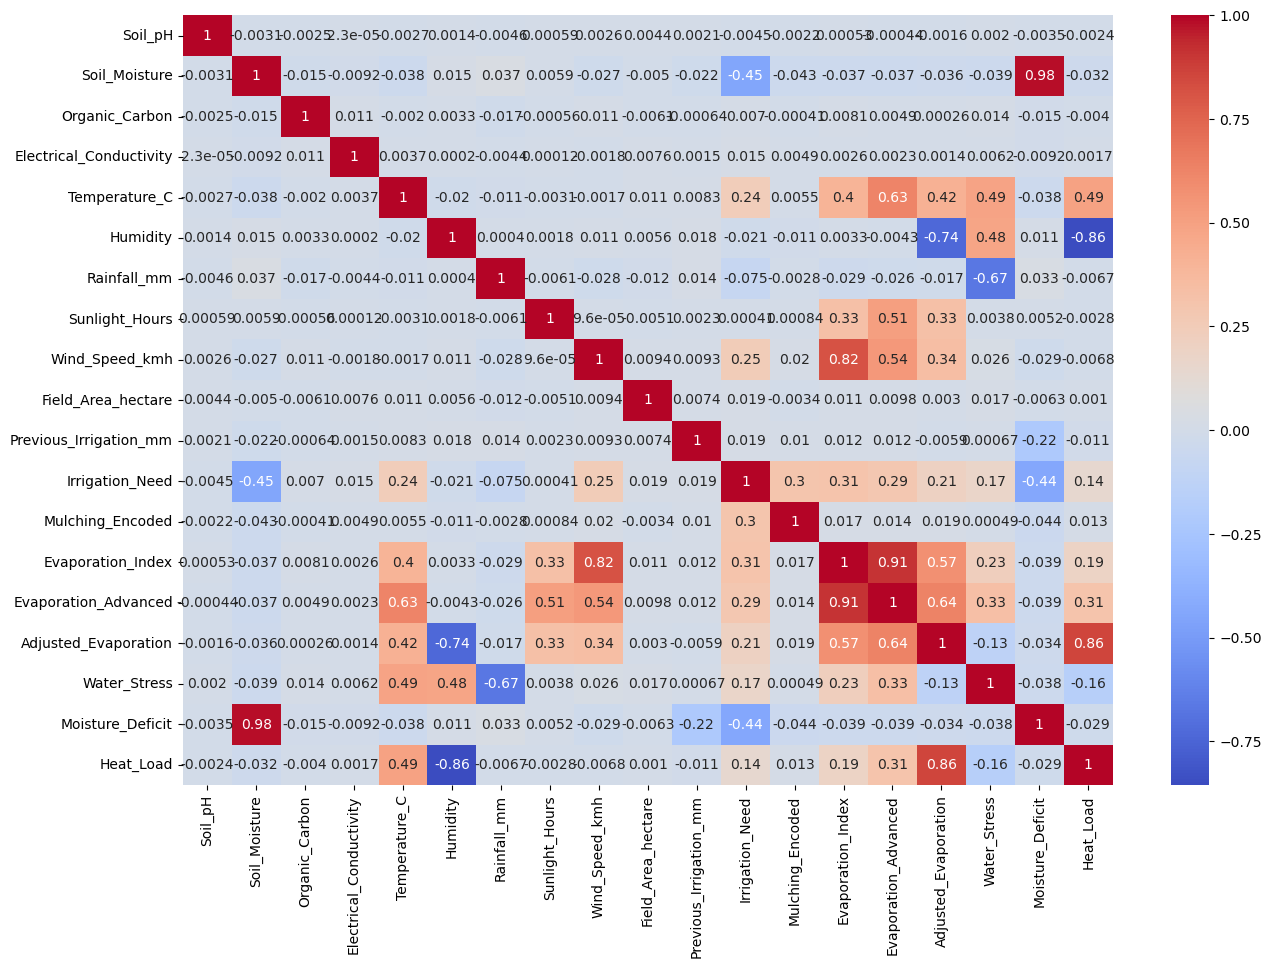

In [234]:
plt.figure(figsize=(15, 10))
corr = df.corr(numeric_only=True,method="spearman")
corr
sns.heatmap(corr, annot=True, cmap='coolwarm')

<Axes: >

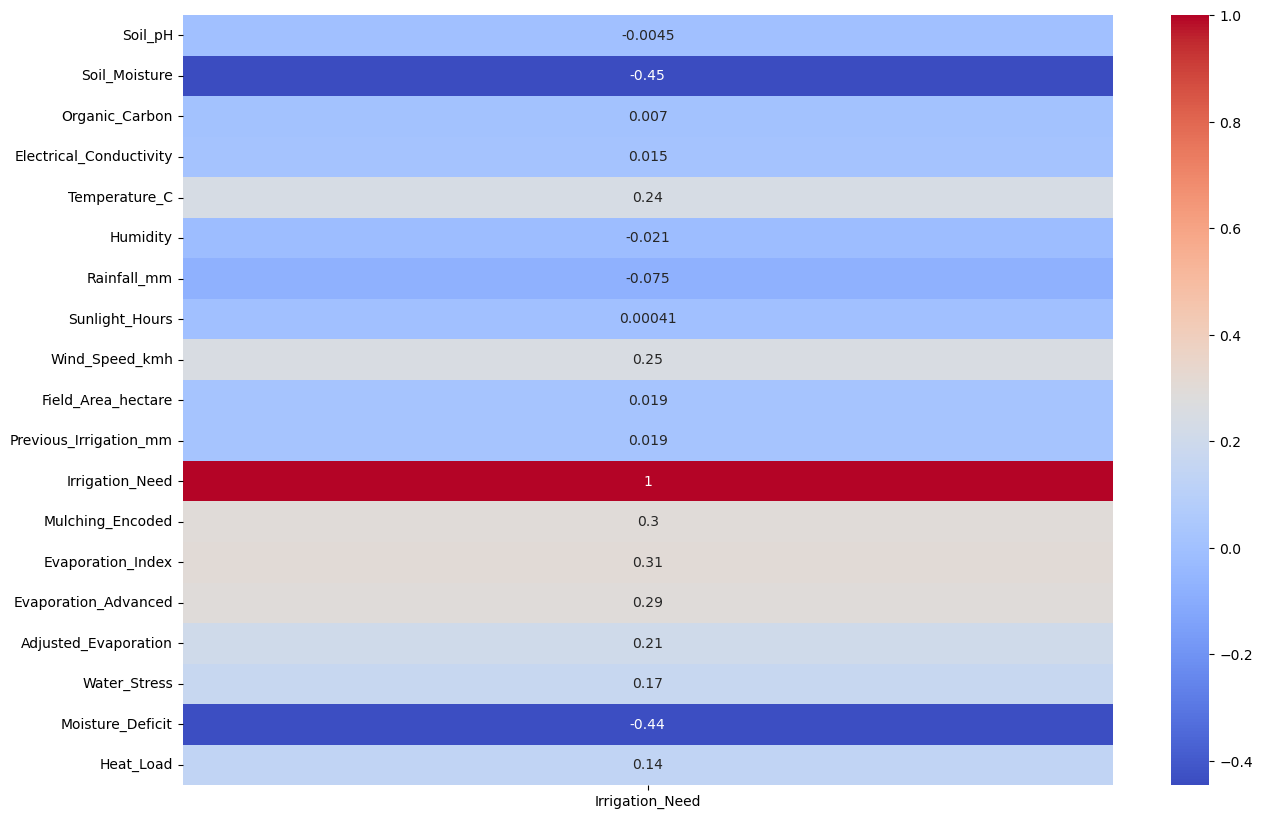

In [235]:
plt.figure(figsize=(15, 10))

spearman_corr = df.corr(numeric_only=True,method='spearman')[['Irrigation_Need']]

sns.heatmap(spearman_corr,annot=True,cmap='coolwarm')




In [236]:
# over = TomekLinks()
# X,y = over.fit_resample(X,y)


# smote = SMOTE(sampling_strategy='minority', random_state=42)
# X_sm, y_sm = smote.fit_resample(X, y)


rus = RandomUnderSampler(random_state=42,sampling_strategy={0: 21009, 1: 21009, 2: 21009})
X_res, y_res = rus.fit_resample(X, y)


In [237]:
model = Sequential([
    Dense(256,input_shape=(X.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(.3),

    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(.2),

    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(.15),

    Dense(32),
    BatchNormalization(),
    Activation('relu'),
    Dropout(.1),
    
    Dense(3, activation='softmax')
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 256)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,163 (203.76 KB)

 Trainable params: 51,203 (200.01 KB)

 Non-trainable params: 960 (3.75 KB)

In [238]:
model.compile( optimizer=Adam(learning_rate=.001),
    loss = 'sparse_categorical_crossentropy',
      metrics = ['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)

checkpoints = ModelCheckpoint(filepath = "model.keras",
                              monitor = 'val_loss',
                              save_best_only = True)

model.fit(X, y, epochs=50,
          validation_split=0.1, batch_size=1024, 
          callbacks=[early_stopping, checkpoints])

Epoch 1/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8561 - loss: 0.3635 - val_accuracy: 0.9317 - val_loss: 0.1881
Epoch 2/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9244 - loss: 0.1977 - val_accuracy: 0.9527 - val_loss: 0.1328
Epoch 3/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9443 - loss: 0.1537 - val_accuracy: 0.9664 - val_loss: 0.1058
Epoch 4/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9570 - loss: 0.1268 - val_accuracy: 0.9705 - val_loss: 0.0937
Epoch 5/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9638 - loss: 0.1120 - val_accuracy: 0.9752 - val_loss: 0.0841
Epoch 6/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9674 - loss: 0.1039 - val_accuracy: 0.9751 - val_loss: 0.0828
Epoch 7/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9697 - loss: 0.0994 - val_accuracy: 0.9755 - val_loss: 0.0811
Epoch 8/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9710 - loss: 0.0959 - val_accuracy: 0.

In [239]:
model.evaluate(X,y)

19688/19688 ━━━━━━━━━━━━━━━━━━━━ 18s 908us/step - accuracy: 0.9819 - loss: 0.0677


[0.06768345087766647, 0.9818872809410095]

In [240]:
from sklearn.metrics import balanced_accuracy_score

In [241]:
pred = model.predict(X)
balanced_accuracy_score(pred.argmax(axis=1),y)

19688/19688 ━━━━━━━━━━━━━━━━━━━━ 14s 705us/step


np.float64(0.9712043054909905)

In [242]:
# model.save("model.keras")
# from tensorflow.keras.models import load_model
# load = load_model("model.keras")

### submission

In [243]:
y_pred = model.predict(df_test)
y_pred = y_pred.argmax(axis=1)
y_pred

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 6s 711us/step


array([0, 0, 0, ..., 1, 0, 1])

In [244]:
sub['Irrigation_Need'] = y_pred
sub['Irrigation_Need'] = sub['Irrigation_Need'].map({0:'Low',1:'Medium' ,2:"High"})

In [245]:
sub.to_csv("sub.csv", index=False)